Requested cases: 15
Cases with BGMM-best: 15
Loaded best contours: 15
Cases retained: 15


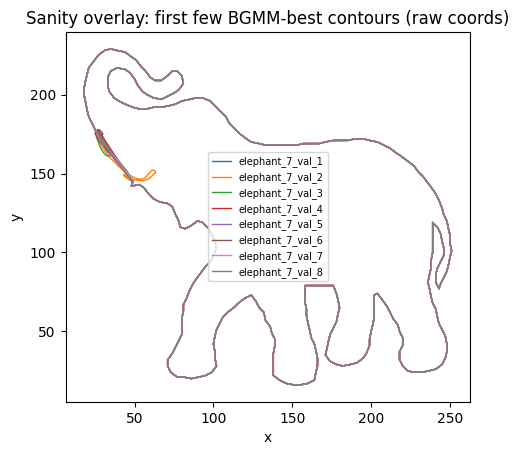

In [4]:
# %%
# ============================================================
# Uses BGMM exports (from the batch BGMM pipeline) instead of certainty_metrics.jsonl.
#
# What it does (focused on what you said you care about):
# 1) For each case: pick a "best" completion from BGMM output
#    Default: cluster_rank=1, top shape by resp.
# 2) Sanity overlay plot of best contours (raw coords) at the start.
# 3) Compute distances:
#    - bb: best–best across cases (upper triangle)
#    - br: best–random within case (K random completions per case)
# 4) Violin plot for Chamfer + RMS
# 5) Ratio = mean(br) / mean(bb) for each metric you plot
# ============================================================

import os
import re
import json
import numpy as np
import matplotlib.pyplot as plt

# ----------------------------
# Settings you can tweak
# ----------------------------
CASES_ROOT = "/home/hschatzle/monte-carlo-selection/data/cases"
BGMM_EXPORTS_ROOT = "/home/hschatzle/monte-carlo-selection/results/bgmm_exports_resnet50_tl_20250829_with_midmaps"

PREFIX = "elephant_7_val_"   # which cases to include
CASE_RANGE = range(1, 16)    # 1..15 inclusive. adjust as needed

# Which BGMM-derived "best" to use
BEST_FROM = "top10_clusters"   # uses <case>/top10_clusters.jsonl
BEST_CLUSTER_RANK = 1          # pick shapes from this cluster rank
BEST_SHAPE_RANK_IN_CLUSTER = 1 # 1 = top resp within that cluster

# Random sampling within-case
RANDOM_PER_CASE = 30
SEED = 123

# Curve processing and RMS metric
N_RESAMPLE = 256
ROTATION_INVARIANT = True
ALLOW_REFLECTION = False
CYCLIC_SHIFTS = 32
EPS = 1e-12

# Which metrics to plot as violins
PLOT_METRICS = ["chamfer", "rms"]


# ----------------------------
# Helpers: BGMM output -> best_png per case
# ----------------------------
def read_jsonl(path):
    rows = []
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if line:
                rows.append(json.loads(line))
    return rows

def pick_best_png_from_bgmm(case_id: str) -> str:
    """
    Reads results/bgmm_exports/<case_id>/top10_clusters.jsonl and chooses:
      cluster_rank == BEST_CLUSTER_RANK, then shapes[BEST_SHAPE_RANK_IN_CLUSTER-1]["png"].
    """
    case_dir = os.path.join(BGMM_EXPORTS_ROOT, case_id)
    top10_path = os.path.join(case_dir, "top10_clusters.jsonl")
    if not os.path.exists(top10_path):
        raise FileNotFoundError(f"Missing BGMM file: {top10_path}")

    rows = read_jsonl(top10_path)

    # Find the desired cluster_rank
    target = None
    for r in rows:
        if int(r.get("cluster_rank", -1)) == int(BEST_CLUSTER_RANK):
            target = r
            break
    if target is None:
        raise RuntimeError(f"Could not find cluster_rank={BEST_CLUSTER_RANK} in {top10_path}")

    shapes = target.get("shapes", [])
    if not shapes:
        raise RuntimeError(f"No shapes in cluster_rank={BEST_CLUSTER_RANK} for {case_id}")

    idx = int(BEST_SHAPE_RANK_IN_CLUSTER) - 1
    idx = max(0, min(idx, len(shapes) - 1))
    best_png = shapes[idx].get("png", None)
    if not best_png:
        raise RuntimeError(f"Missing 'png' for chosen shape in {top10_path}")

    return best_png


# ----------------------------
# Helpers: map png -> polygon xy from shapes_xy.npz
# ----------------------------
def get_xy_for_png(case_id: str, png_path: str) -> np.ndarray:
    npz_path = os.path.join(CASES_ROOT, case_id, "generated", "shapes_xy.npz")
    data = np.load(npz_path, allow_pickle=True)

    polygons = data["polygons"]
    out_files = np.array([str(x) for x in data["out_files"]], dtype=object)
    matlab_1_indexed = bool(data["matlab_1_indexed"]) if "matlab_1_indexed" in data else False

    base = os.path.basename(png_path)

    # Strategy 1: exact basename match
    matches = [i for i, s in enumerate(out_files) if os.path.basename(s) == base]

    # Strategy 2: substring match
    if not matches:
        matches = [i for i, s in enumerate(out_files) if base in s]

    # Strategy 3: parse shape-id from filename, then match
    if not matches:
        m = re.search(r"completion_(\d+)_(\d+)\.png$", base)
        if m:
            shape_id_str = m.group(2)
            shape_id_int = int(shape_id_str)
            matches = [i for i, s in enumerate(out_files) if (shape_id_str in s) or (str(shape_id_int) in s)]

    # Strategy 4: direct indexing guess
    chosen_idx = None
    if matches:
        chosen_idx = int(matches[0])
    else:
        m = re.search(r"completion_(\d+)_(\d+)\.png$", base)
        if m:
            shape_id_int = int(m.group(2))
            idx = shape_id_int - 1 if matlab_1_indexed else shape_id_int
            if 0 <= idx < len(polygons):
                chosen_idx = int(idx)

    if chosen_idx is None:
        raise RuntimeError(f"Could not locate polygon for case_id={case_id} png={png_path}")

    xy = np.asarray(polygons[chosen_idx], dtype=float)
    if xy.ndim != 2 or xy.shape[1] != 2:
        raise ValueError(f"Polygon has unexpected shape {xy.shape} for case_id={case_id}")

    return xy, chosen_idx


def find_polygon_index_for_png(case_id: str, png_path: str) -> int:
    _, idx = get_xy_for_png(case_id, png_path)
    return idx


# ----------------------------
# Helpers: normalize + resample
# ----------------------------
def center_and_scale(xy: np.ndarray) -> np.ndarray:
    xy = np.asarray(xy, float)
    xy = xy - xy.mean(axis=0, keepdims=True)
    r = np.sqrt((xy**2).sum(axis=1)).mean()
    r = max(r, EPS)
    return xy / r

def resample_closed_curve_uniform_arclength(xy: np.ndarray, n: int) -> np.ndarray:
    xy = np.asarray(xy, float)
    if len(xy) < 3:
        raise ValueError("Contour too short")

    if not np.allclose(xy[0], xy[-1]):
        xy = np.vstack([xy, xy[0]])

    seg = np.diff(xy, axis=0)
    seglen = np.sqrt((seg**2).sum(axis=1))
    cum = np.concatenate([[0.0], np.cumsum(seglen)])
    total = cum[-1]
    if total < EPS:
        raise ValueError("Degenerate contour (zero perimeter)")

    t = np.linspace(0.0, total, n + 1)[:-1]
    x = np.interp(t, cum, xy[:, 0])
    y = np.interp(t, cum, xy[:, 1])
    return np.column_stack([x, y])

def prep_curve(xy: np.ndarray) -> np.ndarray:
    return resample_closed_curve_uniform_arclength(center_and_scale(xy), N_RESAMPLE)


# ----------------------------
# Metrics
# ----------------------------
def pairwise_sq_dists(A: np.ndarray, B: np.ndarray) -> np.ndarray:
    D = A[:, None, :] - B[None, :, :]
    return (D * D).sum(axis=2)

def chamfer_symmetric(A: np.ndarray, B: np.ndarray) -> float:
    D2 = pairwise_sq_dists(A, B)
    return float(D2.min(axis=1).mean() + D2.min(axis=0).mean())

def procrustes_rms(A: np.ndarray, B: np.ndarray, rotation: bool, reflect: bool) -> float:
    A0 = A - A.mean(axis=0, keepdims=True)
    B0 = B - B.mean(axis=0, keepdims=True)

    if not rotation:
        diff = A0 - B0
        return float(np.sqrt((diff * diff).sum(axis=1).mean()))

    M = B0.T @ A0
    U, _, Vt = np.linalg.svd(M)
    R = U @ Vt
    if not reflect and np.linalg.det(R) < 0:
        U[:, -1] *= -1
        R = U @ Vt

    B_aligned = B0 @ R
    diff = A0 - B_aligned
    return float(np.sqrt((diff * diff).sum(axis=1).mean()))

def cyclic_shifted_rms(A: np.ndarray, B: np.ndarray, n_shifts: int, rotation: bool, reflect: bool) -> float:
    n = len(B)
    if n_shifts <= 1:
        return procrustes_rms(A, B, rotation=rotation, reflect=reflect)

    shifts = np.linspace(0, n - 1, n_shifts, dtype=int)
    best = np.inf
    for s in shifts:
        d = procrustes_rms(A, np.roll(B, shift=s, axis=0), rotation=rotation, reflect=reflect)
        if d < best:
            best = d
    return float(best)

def dist_bundle(A: np.ndarray, B: np.ndarray) -> dict:
    return {
        "chamfer": chamfer_symmetric(A, B),
        "rms": cyclic_shifted_rms(A, B, n_shifts=CYCLIC_SHIFTS, rotation=ROTATION_INVARIANT, reflect=ALLOW_REFLECTION),
    }


# ----------------------------
# Collect cases and best_pngs from BGMM exports
# ----------------------------
case_ids = [f"{PREFIX}{i}" for i in CASE_RANGE]

best_png_by_case = {}
fail_cases = []

for cid in case_ids:
    try:
        best_png_by_case[cid] = pick_best_png_from_bgmm(cid)
    except Exception as e:
        fail_cases.append((cid, str(e)))

print("Requested cases:", len(case_ids))
print("Cases with BGMM-best:", len(best_png_by_case))
if fail_cases:
    print("Failures (first 5):")
    for row in fail_cases[:5]:
        print(" ", row)


# ----------------------------
# Extract best contours for sanity overlay (raw coords)
# ----------------------------
xy_by_case = {}
best_poly_idx_by_case = {}
fail_xy = []

for cid, best_png in best_png_by_case.items():
    try:
        xy, idx = get_xy_for_png(cid, best_png)
        xy_by_case[cid] = xy
        best_poly_idx_by_case[cid] = int(idx)
    except Exception as e:
        fail_xy.append((cid, str(e)))

print("Loaded best contours:", len(xy_by_case))
if fail_xy:
    print("Best contour failures (first 5):")
    for row in fail_xy[:5]:
        print(" ", row)

case_ids_ok = [cid for cid in case_ids if cid in xy_by_case]
print("Cases retained:", len(case_ids_ok))

# Sanity overlay: first few best-completion contours (raw coordinates)
plt.figure()
for cid in case_ids_ok[:8]:
    xy = np.asarray(xy_by_case[cid], float)
    plt.plot(xy[:, 0], xy[:, 1], linewidth=1, label=cid)
plt.gca().set_aspect("equal", adjustable="box")
plt.title("Sanity overlay: first few BGMM-best contours (raw coords)")
plt.xlabel("x")
plt.ylabel("y")
plt.legend(fontsize=7)
plt.show()




In [5]:
# %%
# ----------------------------
# Build best curves (normalized+resampled) and random curves per case
# ----------------------------
rng = np.random.default_rng(SEED)

best_curves = {}
random_curves = {}  # (case_id, r_i) -> curve

for cid in case_ids_ok:
    best_curves[cid] = prep_curve(xy_by_case[cid])

    # load all polygons for random sampling
    npz_path = os.path.join(CASES_ROOT, cid, "generated", "shapes_xy.npz")
    data = np.load(npz_path, allow_pickle=True)
    polygons = data["polygons"]
    n_total = len(polygons)

    best_i = best_poly_idx_by_case[cid]

    candidates = np.arange(n_total)
    candidates = candidates[candidates != best_i]

    replace = RANDOM_PER_CASE > len(candidates)
    picks = rng.choice(candidates, size=RANDOM_PER_CASE, replace=replace)

    for r_i, idx in enumerate(picks):
        xy = np.asarray(polygons[int(idx)], float)
        random_curves[(cid, r_i)] = prep_curve(xy)

print("Best curves:", len(best_curves))
print("Random curves:", len(random_curves))





Best curves: 15
Random curves: 450


In [6]:
# %%
# ----------------------------
# Compute bb and br distributions
# ----------------------------
def upper_triangle_pairs(ids):
    for i in range(len(ids)):
        for j in range(i + 1, len(ids)):
            yield ids[i], ids[j]

# best–best across cases
bb = {k: [] for k in dist_bundle(best_curves[case_ids_ok[0]], best_curves[case_ids_ok[0]]).keys()}
for a, b in upper_triangle_pairs(case_ids_ok):
    m = dist_bundle(best_curves[a], best_curves[b])
    for k, v in m.items():
        bb[k].append(v)

# best–random within case
br = {k: [] for k in bb.keys()}
for cid in case_ids_ok:
    A = best_curves[cid]
    for r_i in range(RANDOM_PER_CASE):
        B = random_curves[(cid, r_i)]
        m = dist_bundle(A, B)
        for k, v in m.items():
            br[k].append(v)

print("bb counts:", {k: len(v) for k, v in bb.items()})
print("br counts:", {k: len(v) for k, v in br.items()})




bb counts: {'chamfer': 105, 'rms': 105}
br counts: {'chamfer': 450, 'rms': 450}


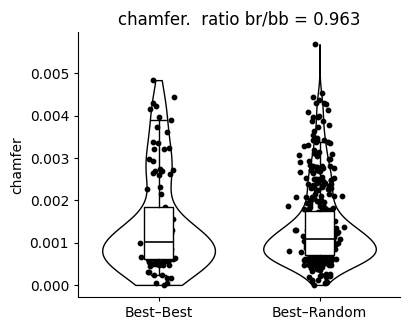

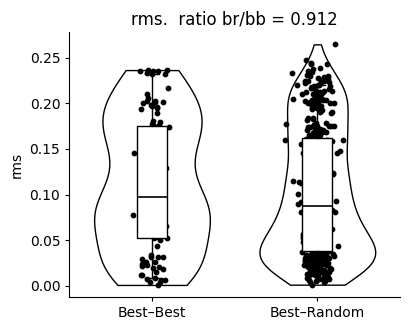


Ratios (mean br / mean bb):
  chamfer -> 0.9634305153175895
  rms -> 0.9116866798889107


In [7]:
# %%
# ----------------------------
# Violin plots + ratios
# ----------------------------
def violin_bb_br(metric_key: str, bb_vals, br_vals, title_extra=""):
    bb_vals = np.asarray(bb_vals, float)
    br_vals = np.asarray(br_vals, float)

    data = [bb_vals, br_vals]
    labels = ["Best–Best", "Best–Random"]
    xpos = [1, 2]

    fig, ax = plt.subplots(figsize=(4.2, 3.4))

    vp = ax.violinplot(
        data,
        positions=xpos,
        widths=0.7,
        showmeans=False,
        showmedians=False,
        showextrema=False
    )

    for body in vp["bodies"]:
        body.set_facecolor("white")
        body.set_edgecolor("black")
        body.set_linewidth(1.0)
        body.set_alpha(1.0)

    bp = ax.boxplot(
        data,
        positions=xpos,
        widths=0.18,
        patch_artist=True,
        showfliers=False,
        whis=(5, 95),
        boxprops=dict(facecolor="white", edgecolor="black", linewidth=1.0),
        medianprops=dict(color="black", linewidth=1.2),
        whiskerprops=dict(color="black", linewidth=1.0),
        capprops=dict(color="black", linewidth=1.0),
    )

    # raw points
    rng_local = np.random.default_rng(0)
    for i, d in enumerate(data, start=1):
        x = rng_local.normal(i, 0.05, size=len(d))
        ax.scatter(x, d, s=10, color="black", alpha=1.0)

    ax.set_xticks(xpos)
    ax.set_xticklabels(labels)
    ax.set_ylabel(metric_key)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.tick_params(axis="both", which="both", length=3)

    ratio = float(br_vals.mean() / (bb_vals.mean() + EPS)) if len(bb_vals) and len(br_vals) else np.nan
    ax.set_title(f"{metric_key}.  ratio br/bb = {ratio:.3f}{title_extra}")

    fig.tight_layout()
    plt.show()

    return ratio

ratios = {}
for k in PLOT_METRICS:
    ratios[k] = violin_bb_br(k, bb[k], br[k])

print("\nRatios (mean br / mean bb):")
for k, r in ratios.items():
    print(" ", k, "->", r)




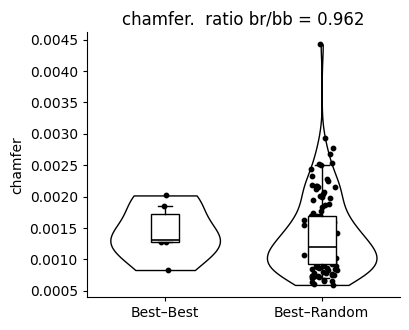

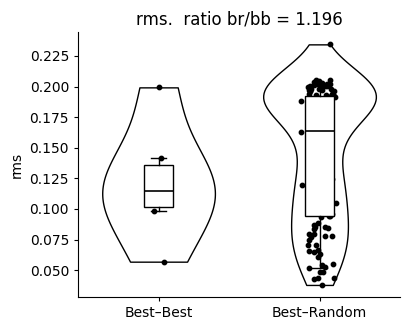

In [16]:
# %%
# Optional: export violin plots for Illustrator (SVG/PDF), one per metric
EXPORT = True
EXPORT_PREFIX = "bgmm_best_violin"

if EXPORT:
    for metric_key in PLOT_METRICS:
        bb_vals = np.asarray(bb[metric_key], float)
        br_vals = np.asarray(br[metric_key], float)

        data = [bb_vals, br_vals]
        labels = ["Best–Best", "Best–Random"]
        xpos = [1, 2]

        fig, ax = plt.subplots(figsize=(4.2, 3.4))

        vp = ax.violinplot(
            data,
            positions=xpos,
            widths=0.7,
            showmeans=False,
            showmedians=False,
            showextrema=False
        )
        for body in vp["bodies"]:
            body.set_facecolor("white")
            body.set_edgecolor("black")
            body.set_linewidth(1.0)
            body.set_alpha(1.0)

        ax.boxplot(
            data,
            positions=xpos,
            widths=0.18,
            patch_artist=True,
            showfliers=False,
            whis=(5, 95),
            boxprops=dict(facecolor="white", edgecolor="black", linewidth=1.0),
            medianprops=dict(color="black", linewidth=1.2),
            whiskerprops=dict(color="black", linewidth=1.0),
            capprops=dict(color="black", linewidth=1.0),
        )

        rng_local = np.random.default_rng(0)
        for i, d in enumerate(data, start=1):
            x = rng_local.normal(i, 0.05, size=len(d))
            ax.scatter(x, d, s=10, color="black", alpha=1.0)

        ax.set_xticks(xpos)
        ax.set_xticklabels(labels)
        ax.set_ylabel(metric_key)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.tick_params(axis="both", which="both", length=3)

        ratio = float(br_vals.mean() / (bb_vals.mean() + EPS)) if len(bb_vals) and len(br_vals) else np.nan
        ax.set_title(f"{metric_key}.  ratio br/bb = {ratio:.3f}")

        fig.tight_layout()
        plt.savefig(f"{EXPORT_PREFIX}_{metric_key}.svg")
        plt.savefig(f"{EXPORT_PREFIX}_{metric_key}.pdf")
        plt.show()

# Euclidean

In [8]:
def curve_to_vec(curve):
    """
    curve: array-like of shape (T,2) or (T,3)
    returns: 1D vector of length T*D
    """
    x = np.asarray(curve, dtype=np.float64)
    if x.ndim != 2:
        raise ValueError(f"Expected curve as 2D array (T,D). Got shape={x.shape}")
    return x.reshape(-1)

def euclid_curve(A, B):
    a = curve_to_vec(A)
    b = curve_to_vec(B)
    if a.shape != b.shape:
        raise ValueError(f"Curves must have same vector length. Got {a.shape} vs {b.shape}")
    return float(np.linalg.norm(a - b))


In [9]:
# %%
# ----------------------------
# Compute bb and br distributions (Euclidean)
# ----------------------------
def upper_triangle_pairs(ids):
    for i in range(len(ids)):
        for j in range(i + 1, len(ids)):
            yield ids[i], ids[j]

METRIC_KEY = "euclid"

bb = {METRIC_KEY: []}
for a, b in upper_triangle_pairs(case_ids_ok):
    bb[METRIC_KEY].append(euclid_curve(best_curves[a], best_curves[b]))

br = {METRIC_KEY: []}
for cid in case_ids_ok:
    A = best_curves[cid]
    for r_i in range(RANDOM_PER_CASE):
        B = random_curves[(cid, r_i)]
        br[METRIC_KEY].append(euclid_curve(A, B))

print("bb counts:", {k: len(v) for k, v in bb.items()})
print("br counts:", {k: len(v) for k, v in br.items()})


bb counts: {'euclid': 105}
br counts: {'euclid': 450}


bb n: 105 mean: 2.4097443240840377
br n: 450 mean: 2.1897235996077424
ratio br/bb: 0.908695407110945


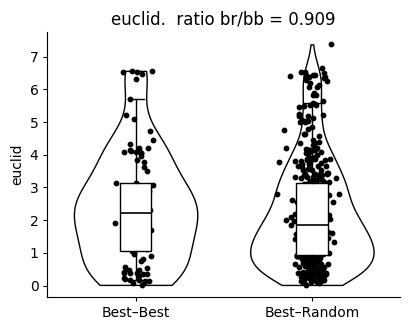

Saved: bgmm_best_violin_euclid.svg
Saved: bgmm_best_violin_euclid.pdf


In [10]:
# %%
# Clean Illustrator-ready export (Euclidean bb vs br)
# Assumes these exist upstream:
#   - case_ids_ok, RANDOM_PER_CASE
#   - best_curves: dict[case_id] -> curve
#   - random_curves: dict[(case_id, r_i)] -> curve
#   - euclid_curve(A,B): returns float
#   - EPS (e.g., 1e-12)
#
# Outputs:
#   - bgmm_best_violin_euclid.svg
#   - bgmm_best_violin_euclid.pdf

import numpy as np
import matplotlib.pyplot as plt

# ----------------------------
# 1) Compute bb and br
# ----------------------------
def upper_triangle_pairs(ids):
    for i in range(len(ids)):
        for j in range(i + 1, len(ids)):
            yield ids[i], ids[j]

METRIC_KEY = "euclid"

bb_vals = []
for a, b in upper_triangle_pairs(case_ids_ok):
    bb_vals.append(float(euclid_curve(best_curves[a], best_curves[b])))

br_vals = []
for cid in case_ids_ok:
    A = best_curves[cid]
    for r_i in range(RANDOM_PER_CASE):
        B = random_curves[(cid, r_i)]
        br_vals.append(float(euclid_curve(A, B)))

bb_vals = np.asarray(bb_vals, dtype=float)
br_vals = np.asarray(br_vals, dtype=float)

print("bb n:", int(np.isfinite(bb_vals).sum()), "mean:", float(np.nanmean(bb_vals)))
print("br n:", int(np.isfinite(br_vals).sum()), "mean:", float(np.nanmean(br_vals)))
ratio = float(np.nanmean(br_vals) / (np.nanmean(bb_vals) + EPS))
print("ratio br/bb:", ratio)

# ----------------------------
# 2) Plot + export (SVG/PDF)
# ----------------------------
EXPORT_PREFIX = "bgmm_best_violin"
EXPORT_SVG = f"{EXPORT_PREFIX}_{METRIC_KEY}.svg"
EXPORT_PDF = f"{EXPORT_PREFIX}_{METRIC_KEY}.pdf"

data = [bb_vals[np.isfinite(bb_vals)], br_vals[np.isfinite(br_vals)]]
labels = ["Best–Best", "Best–Random"]
xpos = [1, 2]

fig, ax = plt.subplots(figsize=(4.2, 3.4))

vp = ax.violinplot(
    data,
    positions=xpos,
    widths=0.7,
    showmeans=False,
    showmedians=False,
    showextrema=False
)
for body in vp["bodies"]:
    body.set_facecolor("white")
    body.set_edgecolor("black")
    body.set_linewidth(1.0)
    body.set_alpha(1.0)

ax.boxplot(
    data,
    positions=xpos,
    widths=0.18,
    patch_artist=True,
    showfliers=False,
    whis=(5, 95),
    boxprops=dict(facecolor="white", edgecolor="black", linewidth=1.0),
    medianprops=dict(color="black", linewidth=1.2),
    whiskerprops=dict(color="black", linewidth=1.0),
    capprops=dict(color="black", linewidth=1.0),
)

# raw points (deterministic jitter)
rng_local = np.random.default_rng(0)
for i, d in enumerate(data, start=1):
    x = rng_local.normal(i, 0.05, size=len(d))
    ax.scatter(x, d, s=10, color="black", alpha=1.0)

ax.set_xticks(xpos)
ax.set_xticklabels(labels)
ax.set_ylabel(METRIC_KEY)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.tick_params(axis="both", which="both", length=3)

ax.set_title(f"{METRIC_KEY}.  ratio br/bb = {ratio:.3f}")

fig.tight_layout()
plt.savefig(EXPORT_SVG)
plt.savefig(EXPORT_PDF)
plt.show()

print("Saved:", EXPORT_SVG)
print("Saved:", EXPORT_PDF)

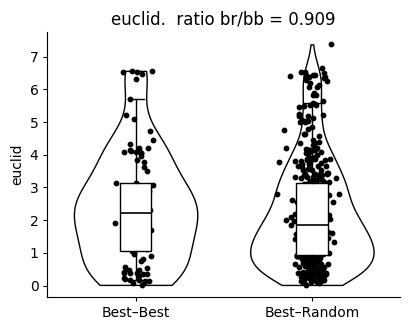


Ratios (mean br / mean bb):
  euclid -> 0.908695407110945


In [11]:
# %%
PLOT_METRICS = [METRIC_KEY]

ratios = {}
for k in PLOT_METRICS:
    ratios[k] = violin_bb_br(k, bb[k], br[k])

print("\nRatios (mean br / mean bb):")
for k, r in ratios.items():
    print(" ", k, "->", r)


In [12]:
# %%
# ----------------------------
# Permutation / bootstrap null for ratio = mean(br)/mean(bb)
# FIX: if dist_bundle() doesn't provide "euclid", compute it directly.
# ----------------------------
import numpy as np
import matplotlib.pyplot as plt

N_PERM = 2000
RNG = np.random.default_rng(0)
EPS = 1e-12

def upper_triangle_pairs(ids):
    for i in range(len(ids)):
        for j in range(i + 1, len(ids)):
            yield ids[i], ids[j]

def euclid_curve(A, B):
    """
    Simple Euclidean distance between two curves.
    Assumes A,B are arrays of shape (T,2) already aligned/resampled to same T.
    Returns RMS Euclidean distance per point (scale-stable across T).
    """
    A = np.asarray(A, dtype=np.float64)
    B = np.asarray(B, dtype=np.float64)
    if A.shape != B.shape:
        raise ValueError(f"Curve shape mismatch: {A.shape} vs {B.shape}. "
                         f"Resample/align curves to same length before euclid.")
    d2 = np.sum((A - B) ** 2, axis=1)          # (T,)
    return float(np.sqrt(np.mean(d2)))         # RMS distance

def euclid_from_bundle(A, B):
    """
    Use dist_bundle if it has euclid-like key. Otherwise fallback to euclid_curve.
    """
    m = dist_bundle(A, B)
    # common fallback names, just in case you used a different label earlier
    for key in ("euclid", "l2", "euclidean", "L2"):
        if key in m:
            return float(m[key])
    return euclid_curve(A, B)

def compute_bb_br_euclid(curves_by_case, random_curves, case_ids_ok, RANDOM_PER_CASE):
    # bb: across cases (one curve per case)
    bb_vals = []
    for a, b in upper_triangle_pairs(case_ids_ok):
        bb_vals.append(euclid_from_bundle(curves_by_case[a], curves_by_case[b]))

    # br: within case (that case curve vs that case randoms)
    br_vals = []
    for cid in case_ids_ok:
        A = curves_by_case[cid]
        for r_i in range(int(RANDOM_PER_CASE)):
            key = (cid, int(r_i))
            if key not in random_curves:
                continue
            B = random_curves[key]
            br_vals.append(euclid_from_bundle(A, B))

    return np.asarray(bb_vals, dtype=np.float64), np.asarray(br_vals, dtype=np.float64)

def ratio_from_bb_br(bb_vals, br_vals, eps=1e-12):
    if bb_vals.size == 0 or br_vals.size == 0:
        return np.nan
    return float(np.mean(br_vals) / (np.mean(bb_vals) + eps))

# --- observed ---
bb_obs, br_obs = compute_bb_br_euclid(best_curves, random_curves, case_ids_ok, RANDOM_PER_CASE)
obs_ratio = ratio_from_bb_br(bb_obs, br_obs)

print("Observed:")
print("  bb n:", int(bb_obs.size), "mean:", float(bb_obs.mean()))
print("  br n:", int(br_obs.size), "mean:", float(br_obs.mean()))
print("  ratio br/bb:", obs_ratio)

# --- null: pseudo-best = random draw per case ---
usable_cases = []
for cid in case_ids_ok:
    avail = [ri for ri in range(int(RANDOM_PER_CASE)) if (cid, ri) in random_curves]
    if len(avail) > 0:
        usable_cases.append(cid)

if len(usable_cases) < len(case_ids_ok):
    missing = sorted(set(case_ids_ok) - set(usable_cases))
    print("WARNING: some cases missing random_curves entries, excluded from null:", missing)

case_ids_null = usable_cases

rat_null = np.full((N_PERM,), np.nan, dtype=np.float64)
for t in range(N_PERM):
    pseudo = {}
    for cid in case_ids_null:
        avail = [ri for ri in range(int(RANDOM_PER_CASE)) if (cid, ri) in random_curves]
        ri = int(RNG.choice(avail))
        pseudo[cid] = random_curves[(cid, ri)]

    bb0, br0 = compute_bb_br_euclid(pseudo, random_curves, case_ids_null, RANDOM_PER_CASE)
    rat_null[t] = ratio_from_bb_br(bb0, br0)

rat_null = rat_null[np.isfinite(rat_null)]
p_one_sided = float((np.sum(rat_null >= obs_ratio) + 1) / (rat_null.size + 1))  # add-1 smoothing
z = float((obs_ratio - rat_null.mean()) / (rat_null.std(ddof=1) + EPS))
ci_lo, ci_hi = np.quantile(rat_null, [0.025, 0.975])

print("\nNull (pseudo-best = random draw per case):")
print("  perms:", int(rat_null.size))
print("  mean:", float(rat_null.mean()), "std:", float(rat_null.std(ddof=1)))
print("  95% null interval:", float(ci_lo), "to", float(ci_hi))
print("  one-sided p (null >= observed):", p_one_sided)
print("  z-score:", z)

# --- visualize ---
fig, ax = plt.subplots(figsize=(6.0, 3.6))
ax.hist(rat_null, bins=40, density=True)
ax.axvline(obs_ratio, linewidth=2)
ax.set_xlabel("ratio = mean(br)/mean(bb)")
ax.set_ylabel("density")
ax.set_title(f"Null ratios (pseudo-best). Observed={obs_ratio:.3f}, p={p_one_sided:.4f}")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()


Observed:
  bb n: 105 mean: 0.15060902025525236
  br n: 450 mean: 0.13685772497548387
  ratio br/bb: 0.9086954071052884


KeyboardInterrupt: 

CASE: elephant_7_val_1
Eligible (from shape_to_cluster.jsonl): 10000
k_argmax unique: 79
ONNX outputs: ['layer2_map', 'layer3_map', 'logits']
Xn: (10000, 1536)
Geometry failures: 0
Pairs used: 80000 out of 49995000
Finite pairs: 80000


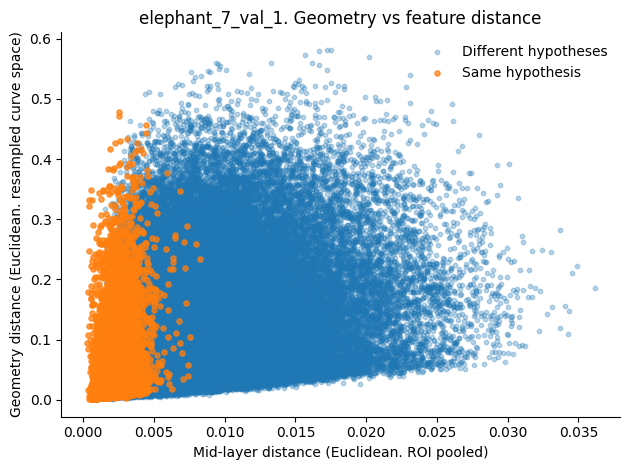

Saved: scatter_geom_vs_mid_elephant_7_val_1.svg and scatter_geom_vs_mid_elephant_7_val_1.pdf


In [13]:
# %%
# ============================================================
# ONE-CASE scatter for Illustrator.
# x = Euclidean distance in mid-layer ROI embedding space (from ONNX midmaps)
# y = Euclidean distance in geometry curve space (your prep_curve output)
# color = same BGMM hypothesis (same k_argmax) vs different
#
# Drop this cell AFTER you have:
#   - case_ids_ok
#   - BGMM_EXPORTS_ROOT, CASES_ROOT
#   - read_jsonl(), get_xy_for_png()
#   - prep_curve()  (your center+scale+resample pipeline)
#   - N_RESAMPLE, EPS already defined (from your script)
# ============================================================

import os, json
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image, ImageDraw
import onnxruntime as ort

# ----------------------------
# CONFIG (edit these only)
# ----------------------------
CASE_ID = case_ids_ok[0]  # or set e.g. "elephant_7_val_3"
ONNX_PATH = "/home/hschatzle/monte-carlo-selection/data/models/resnet50_tl_20250829_with_midmaps.onnx"

# Pair sampling. All pairs can blow up fast.
MAX_PAIRS = 80_000
SEED = 0

# ROI pooling contrast. True = inside minus outside, False = inside only
USE_CONTRAST = True

# Export for Illustrator
EXPORT = True
EXPORT_PREFIX = f"scatter_geom_vs_mid_{CASE_ID}"

# ----------------------------
# Load BGMM assignment file for this case
# ----------------------------
shape2cluster_path = os.path.join(BGMM_EXPORTS_ROOT, CASE_ID, "shape_to_cluster.jsonl")
if not os.path.exists(shape2cluster_path):
    raise FileNotFoundError(f"Missing: {shape2cluster_path}")

rows = read_jsonl(shape2cluster_path)
pngs = [r["png"] for r in rows]
k_argmax = np.array([int(r["k_argmax"]) for r in rows], dtype=int)

print("CASE:", CASE_ID)
print("Eligible (from shape_to_cluster.jsonl):", len(pngs))
print("k_argmax unique:", len(np.unique(k_argmax)))

# ----------------------------
# Build occluder mask in IMAGE space (224x224 after resize)
# We reuse your case JSONL. it sits at CASES_ROOT/<case>/generated/<case>.jsonl
# ----------------------------
case_jsonl = os.path.join(CASES_ROOT, CASE_ID, "generated", f"{CASE_ID}.jsonl")
occluded_png = os.path.join(CASES_ROOT, CASE_ID, "occluded.png")

if not os.path.exists(case_jsonl):
    raise FileNotFoundError(f"Missing: {case_jsonl}")
if not os.path.exists(occluded_png):
    raise FileNotFoundError(f"Missing: {occluded_png}")

last = json.loads(Path(case_jsonl).read_text(encoding="utf-8").splitlines()[-1])
occ_u = np.asarray(last["occluder_rect_xy"], dtype=np.float64)
bounds = last["shape_bounds"]
min_u = np.asarray(bounds["min"], dtype=np.float64)
max_u = np.asarray(bounds["max"], dtype=np.float64)

W_img, H_img = Image.open(occluded_png).size

def unit_to_pixel(u_xy: np.ndarray) -> np.ndarray:
    u = np.asarray(u_xy, dtype=np.float64).reshape(-1, 2)
    x = (u[:, 0] - min_u[0]) / max(1e-12, (max_u[0] - min_u[0])) * (W_img - 1)
    y = (u[:, 1] - min_u[1]) / max(1e-12, (max_u[1] - min_u[1])) * (H_img - 1)
    return np.column_stack([x, y])

occ_px = unit_to_pixel(occ_u)

mask_img = Image.new("L", (W_img, H_img), 0)
draw = ImageDraw.Draw(mask_img)
draw.polygon([(float(x), float(y)) for x, y in occ_px], outline=1, fill=1)
occluder_mask_native = (np.asarray(mask_img, dtype=np.uint8) > 0)

# We will preprocess to 224x224. So resize occluder mask to 224x224 too.
IM_SIZE = 224
m224 = Image.fromarray(occluder_mask_native.astype(np.uint8) * 255).resize((IM_SIZE, IM_SIZE), resample=Image.NEAREST)
occluder_mask_224 = (np.asarray(m224) > 0)

# ----------------------------
# ONNX session + preprocessing
# ----------------------------
so = ort.SessionOptions()
so.intra_op_num_threads = 8
so.inter_op_num_threads = 1

sess = ort.InferenceSession(str(ONNX_PATH), sess_options=so, providers=["CPUExecutionProvider"])
in_name = sess.get_inputs()[0].name
outs = [o.name for o in sess.get_outputs()]
print("ONNX outputs:", outs)

LOGITS_OUT = "logits"
L2_OUT = "layer2_map"
L3_OUT = "layer3_map"
for need in [LOGITS_OUT, L2_OUT, L3_OUT]:
    if need not in outs:
        raise RuntimeError(f"Model outputs {outs}. Missing required output '{need}'")

MEAN = np.array([0.485, 0.456, 0.406], dtype=np.float32)
STD  = np.array([0.229, 0.224, 0.225], dtype=np.float32)

def preprocess_224(png_path: str) -> np.ndarray:
    img = Image.open(png_path).convert("RGB").resize((IM_SIZE, IM_SIZE), resample=Image.BILINEAR)
    x = np.asarray(img, dtype=np.float32) / 255.0
    x = (x - MEAN[None, None, :]) / STD[None, None, :]
    x = np.transpose(x, (2, 0, 1))[None, ...]
    return x.astype(np.float32, copy=False)

def infer_maps(png_path: str):
    x = preprocess_224(png_path)
    l2, l3 = sess.run([L2_OUT, L3_OUT], {in_name: x})
    return np.asarray(l2), np.asarray(l3)

def resize_mask_to_hw(mask_224: np.ndarray, hw):
    H, W = int(hw[0]), int(hw[1])
    m = Image.fromarray(mask_224.astype(np.uint8) * 255).resize((W, H), resample=Image.NEAREST)
    return (np.asarray(m) > 0)

def roi_pool(feat_map: np.ndarray, mask_small: np.ndarray, contrast: bool):
    # feat_map: (1,C,H,W)
    fmap = np.asarray(feat_map)[0]  # (C,H,W)
    inside = mask_small[None, :, :]  # broadcast to (C,H,W)
    outside = ~inside
    eps = 1e-6
    mean_in = (fmap * inside).sum(axis=(1, 2)) / (inside.sum(axis=(1, 2)) + eps)
    if not contrast:
        return mean_in
    mean_out = (fmap * outside).sum(axis=(1, 2)) / (outside.sum(axis=(1, 2)) + eps)
    return mean_in - mean_out

# ----------------------------
# Build embeddings Xn for eligible shapes (in the JSONL order)
# ----------------------------
# Probe one forward pass for dims and mask resizing
l2_0, l3_0 = infer_maps(pngs[0])
mask_l2 = resize_mask_to_hw(occluder_mask_224, l2_0.shape[-2:])  # (28,28)
mask_l3 = resize_mask_to_hw(occluder_mask_224, l3_0.shape[-2:])  # (14,14)

D = int(l2_0.shape[1]) + int(l3_0.shape[1])
X = np.zeros((len(pngs), D), dtype=np.float32)

for i, p in enumerate(pngs):
    l2, l3 = infer_maps(p)
    v2 = roi_pool(l2, mask_l2, contrast=USE_CONTRAST)
    v3 = roi_pool(l3, mask_l3, contrast=USE_CONTRAST)
    X[i] = np.concatenate([v2, v3]).astype(np.float32, copy=False)

# L2-normalize
Xn = X / (np.linalg.norm(X, axis=1, keepdims=True) + 1e-12)
print("Xn:", Xn.shape)

# ----------------------------
# Build geometry curves in the same eligible order
# Uses your get_xy_for_png and prep_curve
# ----------------------------
CURVES = []
bad_geom = 0
for p in pngs:
    try:
        xy, _ = get_xy_for_png(CASE_ID, p)
        CURVES.append(prep_curve(xy))
    except Exception:
        CURVES.append(None)
        bad_geom += 1

print("Geometry failures:", bad_geom)

def curve_euclid(A: np.ndarray, B: np.ndarray) -> float:
    if (A is None) or (B is None):
        return np.nan
    # Euclidean in 2*N_RESAMPLE dims, normalized to be roughly per-point scale
    return float(np.linalg.norm((A - B).reshape(-1)) / np.sqrt(len(A)))

# ----------------------------
# Sample pairs
# ----------------------------
m = int(len(pngs))
all_pairs = m * (m - 1) // 2
rng = np.random.default_rng(SEED)

if (MAX_PAIRS is None) or (all_pairs <= int(MAX_PAIRS)):
    pairs = [(i, j) for i in range(m) for j in range(i + 1, m)]
else:
    pairs = set()
    while len(pairs) < int(MAX_PAIRS):
        i = int(rng.integers(0, m))
        j = int(rng.integers(0, m))
        if i == j:
            continue
        if i > j:
            i, j = j, i
        pairs.add((i, j))
    pairs = list(pairs)

print("Pairs used:", len(pairs), "out of", all_pairs)

# ----------------------------
# Compute distances
# ----------------------------
xd = np.empty((len(pairs),), dtype=np.float32)
yd = np.empty((len(pairs),), dtype=np.float32)
same = np.empty((len(pairs),), dtype=bool)

for t, (i, j) in enumerate(pairs):
    xd[t] = float(np.linalg.norm(Xn[i] - Xn[j]))
    yd[t] = float(curve_euclid(CURVES[i], CURVES[j]))
    same[t] = (k_argmax[i] == k_argmax[j])

ok = np.isfinite(xd) & np.isfinite(yd)
xd, yd, same = xd[ok], yd[ok], same[ok]
print("Finite pairs:", xd.size)

# ----------------------------
# Plot
# ----------------------------
fig, ax = plt.subplots(figsize=(6.4, 4.8))

ax.scatter(xd[~same], yd[~same], s=10, alpha=0.30, label="Different hypotheses")
ax.scatter(xd[same],  yd[same],  s=14, alpha=0.75, label="Same hypothesis")

ax.set_xlabel("Mid-layer distance (Euclidean. ROI pooled)")
ax.set_ylabel("Geometry distance (Euclidean. resampled curve space)")
ax.set_title(f"{CASE_ID}. Geometry vs feature distance")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.legend(frameon=False)

fig.tight_layout()
plt.show()

if EXPORT:
    fig.savefig(f"{EXPORT_PREFIX}.svg")
    fig.savefig(f"{EXPORT_PREFIX}.pdf")
    print("Saved:", f"{EXPORT_PREFIX}.svg", "and", f"{EXPORT_PREFIX}.pdf")

In [14]:
from scipy.stats import pearsonr, spearmanr

r_p, p_p = pearsonr(xd, yd)
r_s, p_s = spearmanr(xd, yd)

print("Pearson r:", r_p, "p:", p_p)
print("Spearman rho:", r_s, "p:", p_s)

Pearson r: 0.25287804 p: 0.0
Spearman rho: 0.28452309528466324 p: 0.0


In [15]:
r_same, p_same = pearsonr(xd[same], yd[same])
r_diff, p_diff = pearsonr(xd[~same], yd[~same])

print("Same cluster r:", r_same, "p:", p_same)
print("Different cluster r:", r_diff, "p:", p_diff)

Same cluster r: 0.22697666 p: 8.797392876509332e-60
Different cluster r: 0.22976387 p: 0.0


Top hypotheses k: [76, 72, 66, 65, 55]
Selected shapes total: 80
Per-cluster cap: 20
Xn shape: (80, 1536)
Pairs used: 3160 / 3160
Finite pairs: 3160


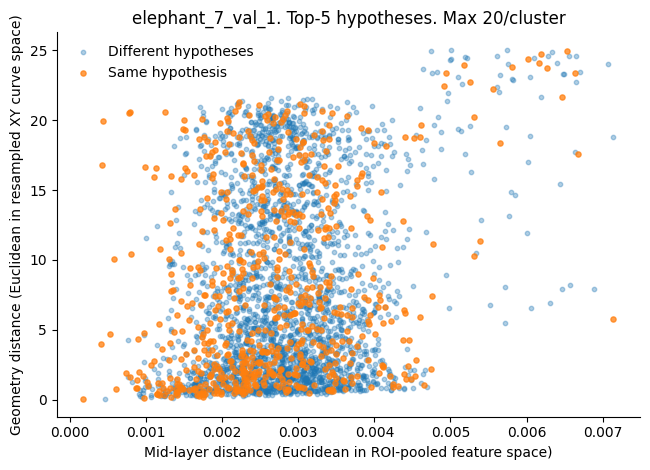

Saved: scatter_geom_vs_mid_elephant_7_val_1_top5_cap20.svg and scatter_geom_vs_mid_elephant_7_val_1_top5_cap20.pdf


In [17]:
# %%
# Scatter (balanced): x = mid-layer embedding distance, y = geometric curve Euclidean distance.
# Color: same BGMM hypothesis (same k_argmax) vs different hypotheses.
# Restrict to TOP_K hypotheses only, and to MAX_PER_CLUSTER shapes per hypothesis.
#
# Reads everything from saved BGMM JSONL exports + shapes_xy.npz, and rebuilds Xn via ROI pooling
# from the ONNX "midmaps" model (layer2_map, layer3_map, logits).
#
# ----------------------------
# CONFIG
# ----------------------------
import os, json, re
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import onnxruntime as ort
from PIL import Image, ImageDraw

CASES_ROOT = "/home/hschatzle/monte-carlo-selection/data/cases"
BGMM_EXPORTS_ROOT = "/home/hschatzle/monte-carlo-selection/results/bgmm_exports_resnet50_tl_20250829_with_midmaps"

CASE_ID = "elephant_7_val_1"                 # one run / one case
ONNX_PATH = "/home/hschatzle/monte-carlo-selection/data/models/resnet50_tl_20250829_with_midmaps.onnx"

TOP_K_HYPOTHESES = 5                         # only compare within top-K hypotheses
MAX_PER_CLUSTER = 20                         # limit shapes per cluster
SEED = 0

# Pair sampling (keeps compute bounded)
MAX_PAIRS = 80_000                           # set None only if very small
N_RESAMPLE = 200                             # curve resample points

# ROI pooling config
USE_CONTRAST = True                          # inside-minus-outside
IM_SIZE = 224
MEAN = np.array([0.485, 0.456, 0.406], dtype=np.float32)
STD  = np.array([0.229, 0.224, 0.225], dtype=np.float32)

# ----------------------------
# Helpers: JSONL + NPZ + occluder mask
# ----------------------------
def read_jsonl(path):
    rows = []
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if line:
                rows.append(json.loads(line))
    return rows

def load_shapes_npz(case_id: str):
    npz_path = os.path.join(CASES_ROOT, case_id, "generated", "shapes_xy.npz")
    data = np.load(npz_path, allow_pickle=True)
    polygons_xy = data["polygons"]
    out_files = np.array([str(x) for x in data["out_files"]], dtype=object)
    matlab_1_indexed = bool(data["matlab_1_indexed"]) if "matlab_1_indexed" in data else False
    return polygons_xy, out_files, matlab_1_indexed, npz_path

def build_occluder_mask_from_case_jsonl(case_id: str):
    case_jsonl = os.path.join(CASES_ROOT, case_id, "generated", f"{case_id}.jsonl")
    occluded_png = os.path.join(CASES_ROOT, case_id, "occluded.png")

    last = json.loads(Path(case_jsonl).read_text(encoding="utf-8").splitlines()[-1])
    occ_u = np.asarray(last["occluder_rect_xy"], dtype=np.float64)
    bounds = last["shape_bounds"]
    min_u = np.asarray(bounds["min"], dtype=np.float64)
    max_u = np.asarray(bounds["max"], dtype=np.float64)

    W_img, H_img = Image.open(occluded_png).size

    def unit_to_pixel(u_xy: np.ndarray) -> np.ndarray:
        u = np.asarray(u_xy, dtype=np.float64).reshape(-1, 2)
        x = (u[:, 0] - min_u[0]) / max(1e-12, (max_u[0] - min_u[0])) * (W_img - 1)
        y = (u[:, 1] - min_u[1]) / max(1e-12, (max_u[1] - min_u[1])) * (H_img - 1)
        return np.column_stack([x, y])

    occ_px = unit_to_pixel(occ_u)

    mask_img = Image.new("L", (W_img, H_img), 0)
    draw = ImageDraw.Draw(mask_img)
    draw.polygon([(float(x), float(y)) for x, y in occ_px], outline=1, fill=1)
    occluder_mask_native = (np.asarray(mask_img, dtype=np.uint8) > 0)

    return occluder_mask_native, occ_px, (W_img, H_img), occluded_png

# ----------------------------
# ONNX: midmaps inference + ROI pooling
# ----------------------------
so = ort.SessionOptions()
so.intra_op_num_threads = 8
so.inter_op_num_threads = 1
SESSION = ort.InferenceSession(str(ONNX_PATH), sess_options=so, providers=["CPUExecutionProvider"])

IN_NAME = SESSION.get_inputs()[0].name
OUTS = [o.name for o in SESSION.get_outputs()]
LOGITS_OUT_NAME = "logits"
L2_MAP_OUT_NAME = "layer2_map"
L3_MAP_OUT_NAME = "layer3_map"

assert LOGITS_OUT_NAME in OUTS, f"Missing '{LOGITS_OUT_NAME}' in outputs {OUTS}"
assert L2_MAP_OUT_NAME in OUTS, f"Missing '{L2_MAP_OUT_NAME}' in outputs {OUTS}"
assert L3_MAP_OUT_NAME in OUTS, f"Missing '{L3_MAP_OUT_NAME}' in outputs {OUTS}"

def preprocess_png(p: str | Path) -> np.ndarray:
    img = Image.open(p).convert("RGB").resize((IM_SIZE, IM_SIZE), resample=Image.BILINEAR)
    x = np.asarray(img, dtype=np.float32) / 255.0
    x = (x - MEAN[None, None, :]) / STD[None, None, :]
    x = np.transpose(x, (2, 0, 1))[None, ...]  # (1,3,224,224)
    return x.astype(np.float32, copy=False)

def infer_maps_and_logits(p: str | Path):
    x = preprocess_png(p)
    l2, l3, logits = SESSION.run([L2_MAP_OUT_NAME, L3_MAP_OUT_NAME, LOGITS_OUT_NAME], {IN_NAME: x})
    return np.asarray(l2), np.asarray(l3), np.asarray(logits).reshape(-1)

def _resize_mask(mask_img: np.ndarray, size_hw):
    H, W = int(size_hw[0]), int(size_hw[1])
    m = Image.fromarray(mask_img.astype(np.uint8) * 255)
    m = m.resize((W, H), resample=Image.NEAREST)
    return (np.asarray(m) > 0)

def _roi_pool_map(feat_map: np.ndarray, mask_small: np.ndarray, contrast: bool):
    # feat_map: (1,C,H,W)
    fmap = np.asarray(feat_map)[0]  # (C,H,W)
    inside = mask_small[None, :, :]   # (1,H,W) broadcasts to (C,H,W)
    outside = ~inside
    eps = 1e-6

    mean_in = (fmap * inside).sum(axis=(1, 2)) / (inside.sum(axis=(1, 2)) + eps)
    if not contrast:
        return mean_in
    mean_out = (fmap * outside).sum(axis=(1, 2)) / (outside.sum(axis=(1, 2)) + eps)
    return mean_in - mean_out

def build_embeddings_Xn(png_paths, occluder_mask_imgspace, use_contrast=True) -> np.ndarray:
    # infer shapes from first
    l2, l3, _ = infer_maps_and_logits(png_paths[0])
    mask_l2 = _resize_mask(occluder_mask_imgspace, l2.shape[-2:])
    mask_l3 = _resize_mask(occluder_mask_imgspace, l3.shape[-2:])

    dim = int(l2.shape[1]) + int(l3.shape[1])  # 512 + 1024
    X = np.zeros((len(png_paths), dim), dtype=np.float32)

    for j, p in enumerate(png_paths):
        l2, l3, _ = infer_maps_and_logits(p)
        v2 = _roi_pool_map(l2, mask_l2, contrast=use_contrast)
        v3 = _roi_pool_map(l3, mask_l3, contrast=use_contrast)
        X[j] = np.concatenate([v2, v3]).astype(np.float32, copy=False)

    # L2 normalize
    norm = np.linalg.norm(X, axis=1, keepdims=True) + 1e-12
    return X / norm

# ----------------------------
# Curve helpers: polyline -> fixed length -> Euclidean
# ----------------------------
def _clean_poly(P):
    P = np.asarray(P, dtype=np.float64).reshape(-1, 2)
    ok = np.isfinite(P).all(axis=1)
    return P[ok]

def _resample_polyline(P, n=N_RESAMPLE):
    P = _clean_poly(P)
    if P.shape[0] < 2:
        return None
    seg = P[1:] - P[:-1]
    seglen = np.linalg.norm(seg, axis=1)
    L = float(np.sum(seglen))
    if not np.isfinite(L) or L <= 1e-12:
        return np.repeat(P[:1], n, axis=0)

    s = np.concatenate([[0.0], np.cumsum(seglen)])
    t = np.linspace(0.0, L, n)

    out = np.zeros((n, 2), dtype=np.float64)
    j = 0
    for i, ti in enumerate(t):
        while j < len(s) - 2 and ti > s[j + 1]:
            j += 1
        s0, s1 = s[j], s[j + 1]
        w = 0.0 if (s1 - s0) <= 1e-12 else (ti - s0) / (s1 - s0)
        out[i] = (1.0 - w) * P[j] + w * P[j + 1]
    return out

def curve_euclid(A, B, n=N_RESAMPLE):
    a = _resample_polyline(A, n=n)
    b = _resample_polyline(B, n=n)
    if a is None or b is None:
        return np.nan
    d = np.linalg.norm((a - b).reshape(-1))
    return float(d / np.sqrt(n))

# ----------------------------
# Load BGMM exports (one case). restrict to top-K hypotheses and MAX_PER_CLUSTER shapes
# ----------------------------
case_dir = os.path.join(BGMM_EXPORTS_ROOT, CASE_ID)
TOP10_JSONL = os.path.join(case_dir, "top10_clusters.jsonl")
ASSIGN_JSONL = os.path.join(case_dir, "shape_to_cluster.jsonl")

if not os.path.exists(TOP10_JSONL):
    raise FileNotFoundError(f"Missing: {TOP10_JSONL}")
if not os.path.exists(ASSIGN_JSONL):
    raise FileNotFoundError(f"Missing: {ASSIGN_JSONL}")

top_rows = read_jsonl(TOP10_JSONL)
assign_rows = read_jsonl(ASSIGN_JSONL)

# pick top-K hypothesis component ids (k) by cluster_rank order in top10_clusters.jsonl
# (top10_clusters is already ordered by "cluster_rank")
top_ks = [int(r["k"]) for r in top_rows[:TOP_K_HYPOTHESES]]
top_ks_set = set(top_ks)
print("Top hypotheses k:", top_ks)

# group eligible shapes by k_argmax, but only for top_ks
cluster_to_rows = {}
for r in assign_rows:
    k = int(r["k_argmax"])
    if k not in top_ks_set:
        continue
    cluster_to_rows.setdefault(k, []).append(r)

rng = np.random.default_rng(SEED)

E_idx = []
k_argmax = []
png_paths = []

for k in top_ks:
    rows = cluster_to_rows.get(int(k), [])
    if len(rows) == 0:
        continue
    if len(rows) > MAX_PER_CLUSTER:
        sel = rng.choice(len(rows), size=MAX_PER_CLUSTER, replace=False)
        rows = [rows[i] for i in sel]
    for r in rows:
        E_idx.append(int(r["global_index"]))
        k_argmax.append(int(r["k_argmax"]))
        png_paths.append(str(r["png"]))

E_idx = np.asarray(E_idx, dtype=np.int64)
k_argmax = np.asarray(k_argmax, dtype=np.int64)

print("Selected shapes total:", int(len(png_paths)))
print("Per-cluster cap:", MAX_PER_CLUSTER)

# ----------------------------
# Load polygons and occluder mask
# ----------------------------
polygons_xy, out_files, matlab_1_indexed, npz_path = load_shapes_npz(CASE_ID)
occluder_mask_native, occ_px, (W_img, H_img), occluded_png_path = build_occluder_mask_from_case_jsonl(CASE_ID)

# ----------------------------
# Build Xn embeddings for selected pngs
# ----------------------------
Xn = build_embeddings_Xn(png_paths, occluder_mask_native, use_contrast=USE_CONTRAST)
print("Xn shape:", tuple(Xn.shape))

# ----------------------------
# Build pair list (all or sampled)
# ----------------------------
m = int(Xn.shape[0])
all_pairs = m * (m - 1) // 2
rng = np.random.default_rng(SEED)

if (MAX_PAIRS is None) or (all_pairs <= int(MAX_PAIRS)):
    pairs = [(i, j) for i in range(m) for j in range(i + 1, m)]
else:
    pairs = set()
    while len(pairs) < int(MAX_PAIRS):
        i = int(rng.integers(0, m))
        j = int(rng.integers(0, m))
        if i == j:
            continue
        if i > j:
            i, j = j, i
        pairs.add((i, j))
    pairs = list(pairs)

print(f"Pairs used: {len(pairs)} / {all_pairs}")

# ----------------------------
# Compute distances
# ----------------------------
xd = np.empty((len(pairs),), dtype=np.float32)   # embedding distance
yd = np.empty((len(pairs),), dtype=np.float32)   # curve distance
same = np.empty((len(pairs),), dtype=bool)       # same hypothesis?

for t, (i, j) in enumerate(pairs):
    xd[t] = float(np.linalg.norm(Xn[i] - Xn[j]))
    yd[t] = curve_euclid(polygons_xy[int(E_idx[i])], polygons_xy[int(E_idx[j])], n=N_RESAMPLE)
    same[t] = (k_argmax[i] == k_argmax[j])

ok = np.isfinite(xd) & np.isfinite(yd)
xd, yd, same = xd[ok], yd[ok], same[ok]
print("Finite pairs:", int(xd.size))

# ----------------------------
# Plot (clean, Illustrator-friendly)
# ----------------------------
fig, ax = plt.subplots(figsize=(6.6, 4.8))

# Different-hypothesis first so same-hypothesis sits on top
ax.scatter(xd[~same], yd[~same], s=10, alpha=0.35, label="Different hypotheses")
ax.scatter(xd[same],  yd[same],  s=14, alpha=0.75, label="Same hypothesis")

ax.set_xlabel("Mid-layer distance (Euclidean in ROI-pooled feature space)")
ax.set_ylabel("Geometry distance (Euclidean in resampled XY curve space)")
ax.set_title(f"{CASE_ID}. Top-{TOP_K_HYPOTHESES} hypotheses. Max {MAX_PER_CLUSTER}/cluster")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.legend(frameon=False)
fig.tight_layout()
plt.show()

# Optional export for Illustrator
EXPORT = True
EXPORT_PREFIX = f"scatter_geom_vs_mid_{CASE_ID}_top{TOP_K_HYPOTHESES}_cap{MAX_PER_CLUSTER}"

if EXPORT:
    fig.savefig(f"{EXPORT_PREFIX}.svg")
    fig.savefig(f"{EXPORT_PREFIX}.pdf")
    print("Saved:", f"{EXPORT_PREFIX}.svg", "and", f"{EXPORT_PREFIX}.pdf")

Pearson r = 0.2052
p-value   = 2.100e-31


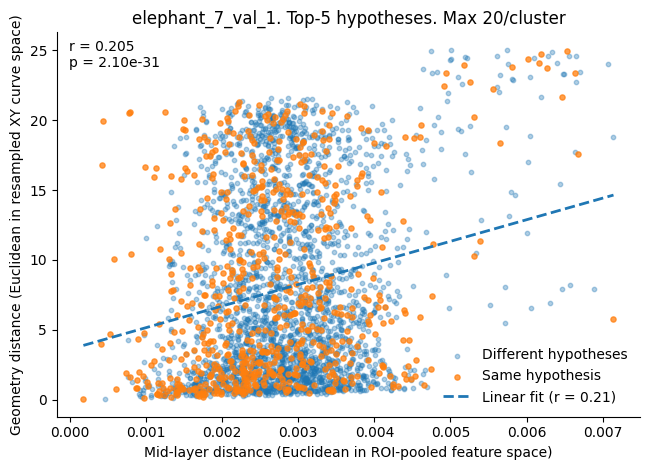

Saved: scatter_geom_vs_mid_elephant_7_val_1_top5_cap20.svg and scatter_geom_vs_mid_elephant_7_val_1_top5_cap20.pdf


In [18]:
# %%
# ---------------------------------------------
# Correlation + Regression + Scatter Plot
# ---------------------------------------------
from scipy import stats

# ----------------------------
# Correlation
# ----------------------------
r, p = stats.pearsonr(xd, yd)
print(f"Pearson r = {r:.4f}")
print(f"p-value   = {p:.3e}")

# ----------------------------
# Linear regression (yd ~ xd)
# ----------------------------
slope, intercept, r_val, p_val, stderr = stats.linregress(xd, yd)

x_line = np.linspace(xd.min(), xd.max(), 200)
y_line = intercept + slope * x_line

# ----------------------------
# Plot
# ----------------------------
fig, ax = plt.subplots(figsize=(6.6, 4.8))

# Different hypotheses first (background)
ax.scatter(
    xd[~same],
    yd[~same],
    s=10,
    alpha=0.35,
    label="Different hypotheses"
)

# Same hypothesis on top
ax.scatter(
    xd[same],
    yd[same],
    s=14,
    alpha=0.75,
    label="Same hypothesis"
)

# Regression line
ax.plot(
    x_line,
    y_line,
    linewidth=2,
    linestyle="--",
    label=f"Linear fit (r = {r:.2f})"
)

ax.set_xlabel("Mid-layer distance (Euclidean in ROI-pooled feature space)")
ax.set_ylabel("Geometry distance (Euclidean in resampled XY curve space)")
ax.set_title(f"{CASE_ID}. Top-{TOP_K_HYPOTHESES} hypotheses. Max {MAX_PER_CLUSTER}/cluster")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Annotate r and p directly in figure
ax.text(
    0.02,
    0.98,
    f"r = {r:.3f}\np = {p:.2e}",
    transform=ax.transAxes,
    verticalalignment="top"
)

ax.legend(frameon=False)
fig.tight_layout()
plt.show()

# ----------------------------
# Export (Illustrator-ready)
# ----------------------------
EXPORT = True
EXPORT_PREFIX = f"scatter_geom_vs_mid_{CASE_ID}_top{TOP_K_HYPOTHESES}_cap{MAX_PER_CLUSTER}"

if EXPORT:
    fig.savefig(f"{EXPORT_PREFIX}.svg")
    fig.savefig(f"{EXPORT_PREFIX}.pdf")
    print("Saved:", f"{EXPORT_PREFIX}.svg", "and", f"{EXPORT_PREFIX}.pdf")